<a href="https://colab.research.google.com/github/febriyansyah-id/COLLAB/blob/main/notebooks/preprocessing/preprocessing_telco_customer_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LAPORAN PREPROCESSING DATASET

# BAB 1 — PENDAHULUAN

Notebook preprocessing Telco Customer Churn disusun dalam beberapa bab agar alur pembahasan mudah diikuti.

## Struktur Bab

**BAB 1 — Pendahuluan**
Latar belakang, tujuan, ruang lingkup, dan konteks churn.

**BAB 2 — Tinjauan Pustaka**
Konsep preprocessing, statistik, visualisasi, dan Big Data.

**BAB 3 — Metodologi**
Dataset, audit kualitas, serta tahapan cleaning dan transformasi.

**BAB 4 — Hasil dan Pembahasan**
Tabel, grafik, hasil transformasi, interpretasi, dan validasi.

**BAB 5 — Kesimpulan dan Saran**
Kesimpulan otomatis, keterbatasan, dan rekomendasi tahap lanjutan.

**Referensi dan Lampiran**
Sumber teori dan kamus implementasi metode.

# Preprocessing Dataset — Telco Customer Churn

## Latar Belakang

Churn adalah kondisi ketika pelanggan berhenti menggunakan layanan perusahaan. Bagi perusahaan telekomunikasi, memahami karakteristik pelanggan yang berhenti penting untuk mempertahankan pelanggan, menentukan strategi layanan, dan mengurangi biaya akuisisi pelanggan baru. Namun, data mentah biasanya belum siap dianalisis karena dapat mengandung nilai kosong, spasi kosong, duplikasi, tipe data yang tidak sesuai, kategori teks, skala numerik yang berbeda, dan nilai ekstrem.

Notebook ini menyajikan preprocessing dataset Telco Customer Churn secara sistematis. Fokusnya adalah menghasilkan data yang konsisten, dapat diaudit, dan siap digunakan untuk analisis eksploratif maupun pemodelan klasifikasi. Preprocessing tidak dimaksudkan untuk menghapus informasi bisnis secara sembarangan; setiap transformasi dijelaskan berdasarkan alasan statistik dan kebutuhan algoritma.

## Susunan Laporan

1. **Latar belakang dan tujuan** — menjelaskan konteks churn serta sasaran preprocessing.
2. **Pemahaman dataset** — mengenali kolom, tipe data, fitur, identifier, dan target.
3. **Metodologi dan audit kualitas** — memeriksa missing value, blank string, duplikasi, tipe data, dan distribusi target.
4. **Tahapan preprocessing** — konversi tipe, imputasi, deduplikasi, penghapusan identifier, encoding, dan standardisasi.
5. **Hasil dalam tabel dan grafik** — membandingkan kondisi sebelum-sesudah dan menjelaskan cara membaca setiap visualisasi.
6. **Validasi, skalabilitas Big Data, kesimpulan, dan referensi** — memastikan output aman digunakan dan dapat dikembangkan.

Dataset yang digunakan adalah data pelanggan telekomunikasi dengan target `Churn`. Identifier pelanggan tidak digunakan sebagai fitur prediktif.

## Tujuan Analisis

Tujuan utama adalah menyiapkan dataset yang dapat diproses algoritma machine learning tanpa menghilangkan makna bisnisnya. Secara khusus, notebook ini bertujuan untuk: (1) menemukan masalah kualitas data, (2) memperbaiki nilai dan tipe data yang tidak sesuai, (3) mengubah variabel kategorikal menjadi representasi numerik, (4) menyetarakan skala fitur numerik, (5) membandingkan hasil sebelum dan sesudah preprocessing melalui tabel serta grafik, dan (6) menghasilkan kesimpulan otomatis berdasarkan nilai aktual setelah notebook dijalankan.

Output akhir bukan model prediksi churn. Output akhir adalah dataset bersih dan tervalidasi yang menjadi input untuk tahap analisis atau pemodelan berikutnya.

## Bab 2 — Tinjauan Pustaka

### 2.1 Preprocessing Data
Preprocessing adalah rangkaian kegiatan untuk mengubah data mentah menjadi data yang konsisten dan siap dianalisis. Tahap ini meliputi pemeriksaan kualitas, perbaikan tipe data, penanganan missing value, penghapusan duplikasi, encoding kategori, dan standardisasi numerik.

### 2.2 Missing Value dan Imputasi Median
Missing value adalah nilai yang tidak tersedia atau tidak terbaca. Imputasi median mengganti nilai kosong dengan nilai tengah sehingga lebih tahan terhadap outlier dibandingkan mean. Parameter median sebaiknya dihitung dari data training saja pada pemodelan prediktif.

### 2.3 Duplikasi dan Identifier
Duplikasi dapat membuat observasi tertentu dihitung lebih dari sekali dan menyebabkan bias. Identifier seperti `customerID` hanya berfungsi sebagai penanda baris, sehingga tidak digunakan sebagai fitur prediktif karena tidak mewakili karakteristik pelanggan.

### 2.4 IQR dan Boxplot
IQR dihitung dengan rumus `Q3 − Q1`. Kandidat outlier berada di bawah `Q1 − 1,5 × IQR` atau di atas `Q3 + 1,5 × IQR`. Boxplot menampilkan median, kuartil, whisker, dan kandidat outlier. Nilai ekstrem tidak otomatis dihapus karena dapat merupakan kondisi pelanggan yang valid.

### 2.5 Encoding dan Standardisasi
Encoding mengubah kategori teks menjadi fitur numerik. One-hot encoding membuat indikator 0/1 tanpa mengasumsikan urutan kategori. StandardScaler menggunakan z-score `(x − mean) / standard deviation` agar fitur numerik memiliki skala yang sebanding.

### 2.6 Statistik Deskriptif dan Visualisasi
Mean, median, kuartil, standar deviasi, minimum, dan maksimum digunakan untuk memahami pusat serta penyebaran data. Histogram memperlihatkan distribusi, boxplot membantu mendeteksi kandidat outlier, sedangkan tabel memberikan angka yang dapat diaudit.

### 2.7 Prinsip Big Data
Pada data besar, preprocessing perlu mempertimbangkan volume, velocity, variety, veracity, dan value. Teknik seperti pemrosesan per chunk, format Parquet, sparse matrix, Spark/Dask, schema validation, logging, dan data versioning membantu menjaga efisiensi serta konsistensi pipeline.

## Tujuan dan Prinsip

Tujuan tugas adalah menghasilkan dataset numerik yang konsisten dan siap untuk analisis atau pemodelan. Setiap perubahan harus memiliki alasan: missing value ditangani berdasarkan tipe data, kategori di-encoding karena tidak memiliki jarak numerik alami, dan standardisasi diterapkan agar fitur numerik memiliki skala sebanding.

Notebook ini mempertahankan dataset mentah di memori sebagai `raw`, sehingga kondisi sebelum dan sesudah dapat dibandingkan.

In [42]:
%pip install -q pandas numpy matplotlib seaborn scikit-learn

In [43]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
sns.set_theme(style='whitegrid')
DATA_PATH = Path('Telco-Customer-Churn.csv')
OUTPUT_PATH = Path('Telco-Customer-Churn-preprocessed.csv')
if not DATA_PATH.exists():
    raise FileNotFoundError(f'File tidak ditemukan: {DATA_PATH.resolve()}')
raw = pd.read_csv(DATA_PATH)
df = raw.copy()
print('Ukuran awal:', raw.shape)
display(raw.head())

Ukuran awal: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# BAB 3 — METODOLOGI

## 3.1 Pemahaman Dataset

Kolom numerik utama adalah `SeniorCitizen`, `tenure`, `MonthlyCharges`, dan `TotalCharges`. Kolom layanan, kontrak, pembayaran, dan demografi bersifat kategorikal. `Churn` adalah target biner dengan label `Yes` dan `No`. `customerID` hanya identifier dan akan dihapus sebelum pemodelan.

In [44]:
numeric_candidates = ['SeniorCitizen','tenure','MonthlyCharges','TotalCharges']
categorical_candidates = [c for c in raw.columns if c not in numeric_candidates + ['customerID','Churn']]
print('Kolom:', list(raw.columns))
print('Numerik:', numeric_candidates)
print('Kategorikal:', categorical_candidates)
print('Distribusi target:')
display(raw['Churn'].value_counts(dropna=False).rename_axis('Churn').to_frame('Jumlah'))

Kolom: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
Numerik: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Kategorikal: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Distribusi target:


,Jumlah
Churn,
No,5174
Yes,1869


## 3.2 Audit Kualitas Data

Audit mencakup missing value, blank string, format numerik, duplikasi, dan distribusi target. Blank string diperiksa terpisah karena Pandas tidak selalu membacanya sebagai `NaN`.

In [45]:
blank = raw.astype('string').apply(lambda c: c.str.strip().eq('').sum())
audit = pd.DataFrame({'dtype':raw.dtypes.astype(str),'missing':raw.isna().sum(),'blank':blank,'unique':raw.nunique(dropna=False)})
print('Duplikasi mentah:', int(raw.duplicated().sum()))
display(audit)
total_numeric = pd.to_numeric(raw['TotalCharges'], errors='coerce')
print('TotalCharges gagal dikonversi:', int(total_numeric.isna().sum() - raw['TotalCharges'].isna().sum()))

Duplikasi mentah: 0


,dtype,missing,blank,unique
customerID,object,0,0,7043
gender,object,0,0,2
SeniorCitizen,int64,0,0,2
Partner,object,0,0,2
Dependents,object,0,0,2
tenure,int64,0,0,73
PhoneService,object,0,0,2
MultipleLines,object,0,0,3
InternetService,object,0,0,3
OnlineSecurity,object,0,0,3


TotalCharges gagal dikonversi: 11


## 3.3 Pemeriksaan Outlier dengan IQR

IQR digunakan sebagai pemeriksaan, bukan alasan otomatis untuk membuang data. Nilai ekstrem dapat merupakan pelanggan nyata, sehingga keputusan penghapusan perlu dukungan konteks domain.

In [46]:
temp = raw.copy()
temp['TotalCharges'] = pd.to_numeric(temp['TotalCharges'], errors='coerce')
outliers=[]
for col in ['tenure','MonthlyCharges','TotalCharges']:
    q1,q3=temp[col].quantile([.25,.75]); iqr=q3-q1
    lo,hi=q1-1.5*iqr,q3+1.5*iqr
    outliers.append({'Kolom':col,'Q1':q1,'Q3':q3,'Batas bawah':lo,'Batas atas':hi,'Jumlah outlier':int(((temp[col]<lo)|(temp[col]>hi)).sum())})
display(pd.DataFrame(outliers))

,Kolom,Q1,Q3,Batas bawah,Batas atas,Jumlah outlier
0,tenure,9.00,55.0000,-60.00000,124.00000,0
1,MonthlyCharges,35.50,89.8500,-46.02500,171.37500,0
2,TotalCharges,401.45,3794.7375,-4688.48125,8884.66875,0


## 3.4 Cleaning dan Transformasi

String kosong `TotalCharges` diubah menjadi missing dan diimputasi dengan median. Median dipilih karena lebih tahan terhadap nilai ekstrem. Identifier `customerID` dihapus, duplikasi dibuang setelah ID dihapus, `Churn` diubah menjadi 0/1, fitur kategorikal di-one-hot encode, dan fitur numerik distandardisasi.

Catatan metodologis: untuk pemodelan prediktif, scaler idealnya di-fit setelah train-test split dan hanya pada data training untuk mencegah data leakage.

In [47]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(r'^\s*$', pd.NA, regex=True), errors='coerce')
missing_before = int(df.isna().sum().sum())
median_total = df['TotalCharges'].median()
df['TotalCharges'] = df['TotalCharges'].fillna(median_total)
rows_before = len(df)
df = df.drop(columns=['customerID']).drop_duplicates().reset_index(drop=True)
df['Churn'] = df['Churn'].map({'No':0,'Yes':1})
numeric = ['SeniorCitizen','tenure','MonthlyCharges','TotalCharges']
categorical = [c for c in df.columns if c not in numeric + ['Churn']]
df[numeric] = StandardScaler().fit_transform(df[numeric])
df = pd.get_dummies(df, columns=categorical, dtype=int)
print('Missing sebelum imputasi:', missing_before)
print('Median TotalCharges:', median_total)
print('Ukuran akhir:', df.shape)

Missing sebelum imputasi: 11
Median TotalCharges: 1397.475
Ukuran akhir: (7021, 46)


# BAB 4 — HASIL DAN PEMBAHASAN

## 4.1 Perbandingan dan Visualisasi

Perbandingan ini menunjukkan dampak cleaning dan encoding. Jumlah kolom dapat bertambah karena satu kolom kategorikal dipecah menjadi beberapa indikator biner.

,Sebelum,Sesudah
Baris,7043,7021
Kolom,21,46
Missing NaN,0,0
Duplikasi,0,0


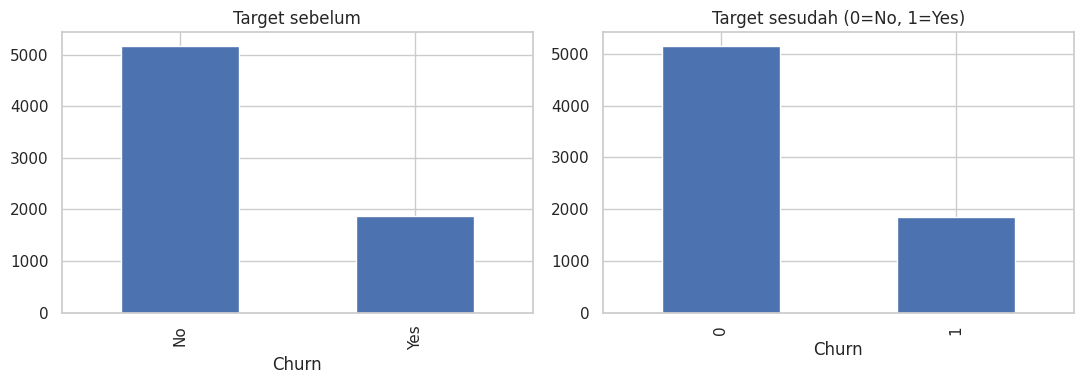

In [48]:
comparison = pd.DataFrame({'Sebelum':[raw.shape[0],raw.shape[1],int(raw.isna().sum().sum()),int(raw.duplicated().sum())],'Sesudah':[df.shape[0],df.shape[1],int(df.isna().sum().sum()),int(df.duplicated().sum())]}, index=['Baris','Kolom','Missing NaN','Duplikasi'])
display(comparison)
fig,ax=plt.subplots(1,2,figsize=(11,4))
raw['Churn'].value_counts().plot.bar(ax=ax[0],title='Target sebelum')
df['Churn'].value_counts().sort_index().plot.bar(ax=ax[1],title='Target sesudah (0=No, 1=Yes)')
plt.tight_layout(); plt.show()

## 3.5 Validasi dan Penyimpanan

Dataset hanya disimpan setelah seluruh validasi berhasil: tidak ada missing value, tidak ada duplikasi, target tetap biner, dan semua kolom bersifat numerik.

In [49]:
assert df.isna().sum().sum() == 0
assert df.duplicated().sum() == 0
assert 'Churn' in df.columns
assert set(df['Churn'].unique()).issubset({0,1})
assert all(pd.api.types.is_numeric_dtype(t) for t in df.dtypes)
df.to_csv(OUTPUT_PATH,index=False)
print('VALIDATION: PASS')
print('Tersimpan:', OUTPUT_PATH.resolve())

VALIDATION: PASS
Tersimpan: /content/Telco-Customer-Churn-preprocessed.csv


In [50]:
# Kesimpulan otomatis berbasis hasil aktual
removed_rows = raw.shape[0] - df.shape[0]
added_cols = df.shape[1] - raw.shape[1]
churn_rate = df['Churn'].mean()
print('='*70)
print('ANALISIS OTOMATIS')
print('='*70)
print(f'- Ukuran: {raw.shape} -> {df.shape}')
print(f'- Baris yang berkurang: {removed_rows}')
print(f'- Kolom yang bertambah karena encoding: {added_cols}')
print(f'- Missing value akhir: {int(df.isna().sum().sum())}')
print(f'- Duplikasi akhir: {int(df.duplicated().sum())}')
print(f'- Proporsi churn: {churn_rate:.2%}')
print('KESIMPULAN: dataset sudah numerik, bersih, tervalidasi, dan siap untuk analisis/modeling.')
if churn_rate < .4 or churn_rate > .6: print('CATATAN: target tidak seimbang; gunakan precision, recall, F1-score, dan confusion matrix.')
print('CATATAN: fit scaler pada data training saja ketika membangun model prediktif.')

ANALISIS OTOMATIS
- Ukuran: (7043, 21) -> (7021, 46)
- Baris yang berkurang: 22
- Kolom yang bertambah karena encoding: 25
- Missing value akhir: 0
- Duplikasi akhir: 0
- Proporsi churn: 26.45%
KESIMPULAN: dataset sudah numerik, bersih, tervalidasi, dan siap untuk analisis/modeling.
CATATAN: target tidak seimbang; gunakan precision, recall, F1-score, dan confusion matrix.
CATATAN: fit scaler pada data training saja ketika membangun model prediktif.


## Kesimpulan Laporan

Preprocessing menghasilkan data yang bebas missing value dan duplikasi, memiliki target numerik, fitur kategorikal yang telah di-encoding, serta fitur numerik yang telah distandardisasi. Sel kesimpulan otomatis menyajikan ukuran aktual dan peringatan ketidakseimbangan target setelah notebook dijalankan. Tahap lanjutan adalah train-test split, pipeline preprocessing yang mencegah leakage, pemodelan klasifikasi, dan evaluasi dengan metrik yang sesuai.

# BAB 4 — HASIL DAN PEMBAHASAN (LANJUTAN)

## 4.2 Dashboard Ringkasan Hasil

Bagian ini menyajikan hasil preprocessing dalam beberapa bentuk agar perubahan data mudah dipahami. Tabel membantu membaca angka secara tepat, sedangkan grafik membantu melihat pola distribusi, missing value, outlier, dan perubahan ukuran fitur.

In [51]:
# Tabel ringkasan kualitas data sebelum dan sesudah
quality_table = pd.DataFrame({
    'Metrik':['Baris','Kolom','Missing value','Duplikasi','Kolom numerik','Kolom kategorikal'],
    'Sebelum':[raw.shape[0],raw.shape[1],int(raw.isna().sum().sum()),int(raw.duplicated().sum()),len(raw.select_dtypes(include=np.number).columns),len(raw.select_dtypes(exclude=np.number).columns)],
    'Sesudah':[df.shape[0],df.shape[1],int(df.isna().sum().sum()),int(df.duplicated().sum()),len(df.select_dtypes(include=np.number).columns),0]
})
display(quality_table)

,Metrik,Sebelum,Sesudah
0,Baris,7043,7021
1,Kolom,21,46
2,Missing value,0,0
3,Duplikasi,0,0
4,Kolom numerik,3,46
5,Kolom kategorikal,18,0


,Jumlah,Persentase
Status,,
No,5174,73.46
Yes,1869,26.54


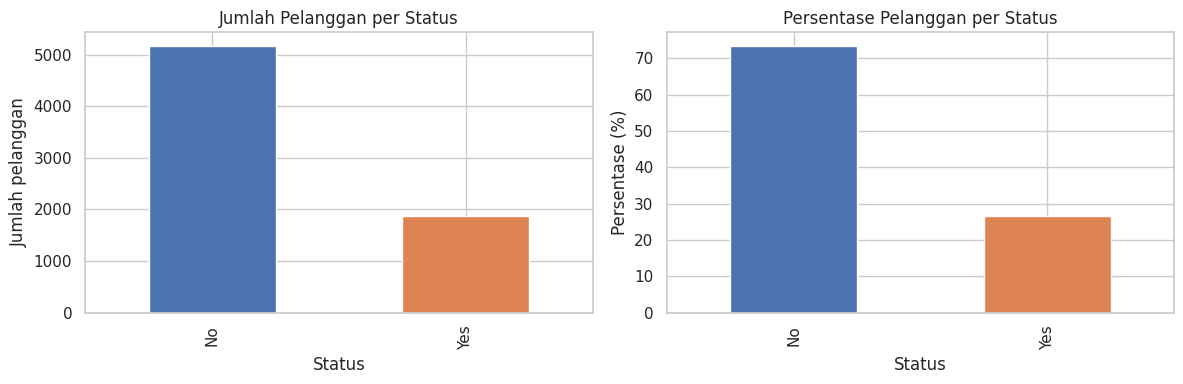

In [52]:
# Distribusi target dalam jumlah dan persentase
target_table = raw['Churn'].value_counts(dropna=False).rename_axis('Status').to_frame('Jumlah')
target_table['Persentase'] = (target_table['Jumlah'] / target_table['Jumlah'].sum() * 100).round(2)
display(target_table)
fig, ax = plt.subplots(1,2,figsize=(12,4))
target_table['Jumlah'].plot(kind='bar', ax=ax[0], color=['#4C72B0','#DD8452'], title='Jumlah Pelanggan per Status')
target_table['Persentase'].plot(kind='bar', ax=ax[1], color=['#4C72B0','#DD8452'], title='Persentase Pelanggan per Status')
ax[0].set_ylabel('Jumlah pelanggan'); ax[1].set_ylabel('Persentase (%)')
plt.tight_layout(); plt.show()

,count,mean,std,min,25%,50%,75%,max,range
tenure,7043.0,32.37,24.56,0.00,9.00,29.00,55.00,72.00,72.0
MonthlyCharges,7043.0,64.76,30.09,18.25,35.50,70.35,89.85,118.75,100.5
TotalCharges,7032.0,2283.30,2266.77,18.80,401.45,1397.48,3794.74,8684.80,8666.0


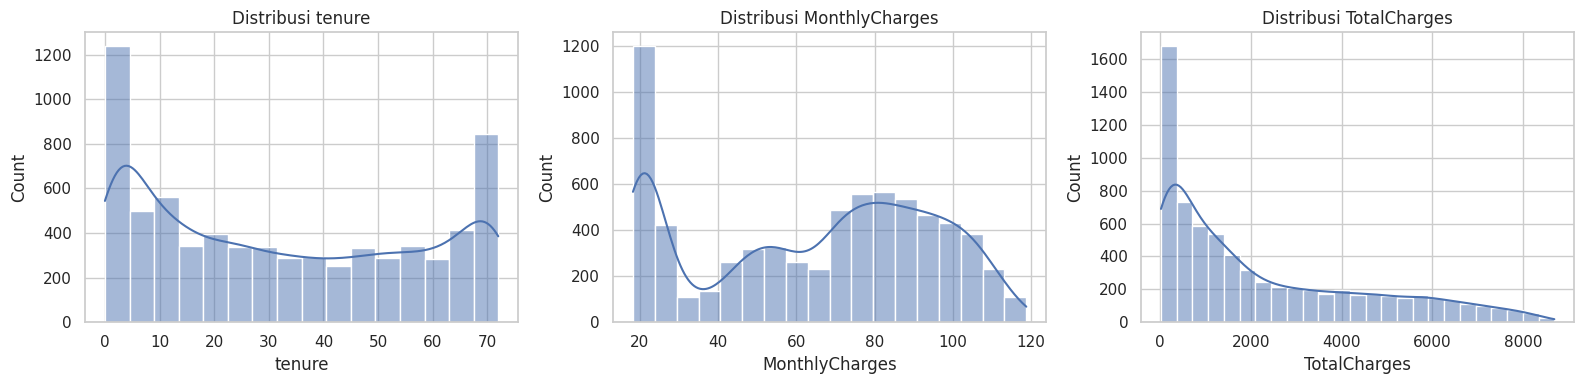

In [53]:
# Statistik deskriptif numerik dengan interpretasi ringkas
numeric_view = temp[['tenure','MonthlyCharges','TotalCharges']].describe().T
numeric_view['range'] = numeric_view['max'] - numeric_view['min']
display(numeric_view.round(2))
fig, ax = plt.subplots(1,3,figsize=(16,4))
for axis, col in zip(ax, ['tenure','MonthlyCharges','TotalCharges']):
    sns.histplot(temp[col].dropna(), kde=True, ax=axis, color='#4C72B0')
    axis.set_title(f'Distribusi {col}')
plt.tight_layout(); plt.show()

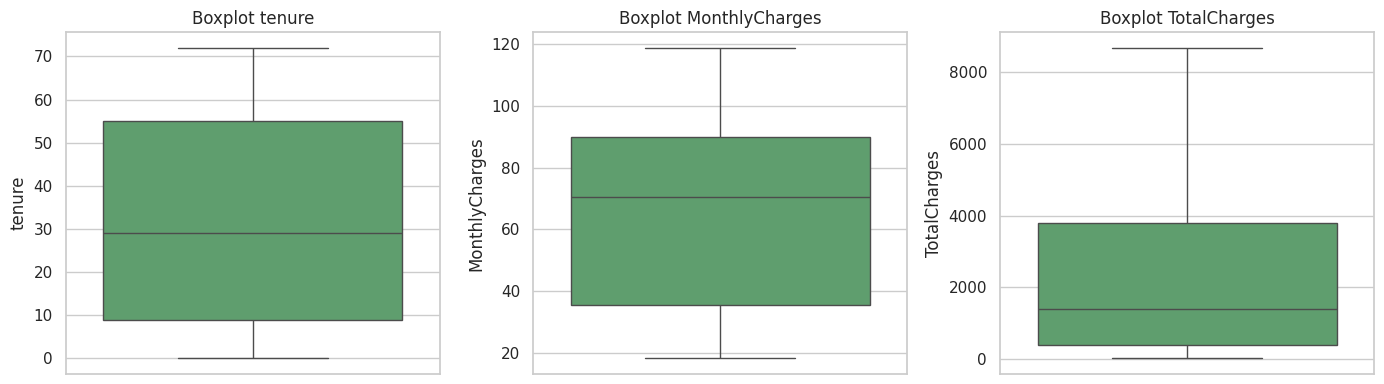

In [54]:
# Boxplot untuk melihat sebaran dan kemungkinan outlier
fig, ax = plt.subplots(1,3,figsize=(14,4))
for axis, col in zip(ax, ['tenure','MonthlyCharges','TotalCharges']):
    sns.boxplot(y=temp[col], ax=axis, color='#55A868')
    axis.set_title(f'Boxplot {col}')
plt.tight_layout(); plt.show()

In [55]:
# Heatmap missing value sebelum preprocessing
missing_view = raw.isna().sum().sort_values(ascending=False)
missing_view = missing_view[missing_view > 0]
if len(missing_view):
    plt.figure(figsize=(8,3))
    sns.barplot(x=missing_view.values, y=missing_view.index, color='#C44E52')
    plt.title('Missing Value Sebelum Preprocessing')
    plt.xlabel('Jumlah missing value'); plt.ylabel('Kolom'); plt.show()
else:
    print('Tidak ada missing value eksplisit pada pembacaan awal.')

Tidak ada missing value eksplisit pada pembacaan awal.


## 4.3 Interpretasi Hasil

- Jika jumlah baris akhir lebih kecil, pengurangan berasal dari duplikasi yang dihapus; data asli tetap dipertahankan pada variabel `raw`.
- Jika jumlah kolom bertambah, penyebab utamanya adalah one-hot encoding terhadap kategori.
- Missing value `TotalCharges` ditangani setelah string kosong dikonversi menjadi nilai kosong yang dikenali Pandas.
- Histogram memperlihatkan bentuk distribusi, sedangkan boxplot membantu memeriksa nilai ekstrem. Outlier tidak otomatis berarti kesalahan.
- Grafik target menunjukkan apakah kelas churn seimbang. Jika tidak seimbang, accuracy saja tidak cukup untuk evaluasi model.
- Dataset akhir harus dibaca bersama tabel validasi, bukan hanya dilihat dari grafik.

In [56]:
# Kesimpulan otomatis yang lebih detail
initial_missing = int(raw.isna().sum().sum())
final_missing = int(df.isna().sum().sum())
duplicate_removed = int(raw.shape[0] - df.shape[0])
majority_status = target_table['Jumlah'].idxmax()
majority_pct = float(target_table.loc[majority_status,'Persentase'])
print('='*80)
print('KESIMPULAN OTOMATIS')
print('='*80)
print(f'1. Dataset awal memiliki {raw.shape[0]:,} baris dan {raw.shape[1]:,} kolom.')
print(f'2. Dataset akhir memiliki {df.shape[0]:,} baris dan {df.shape[1]:,} kolom.')
print(f'3. Sebanyak {duplicate_removed:,} baris hilang setelah pembersihan duplikasi.')
print(f'4. Missing value: {initial_missing:,} pada awal proses dan {final_missing:,} setelah preprocessing.')
print(f'5. Kelas mayoritas adalah {majority_status} dengan proporsi {majority_pct:.2f}%.')
print('6. Fitur numerik yang distandardisasi: ' + ', '.join(numeric) + '.')
print('7. Fitur kategorikal telah diubah menjadi representasi one-hot.')
print('8. Validasi akhir memastikan seluruh kolom numerik, target biner, tanpa missing value, dan tanpa duplikasi.')
print('9. Untuk pemodelan, gunakan train-test split sebelum fitting scaler dan evaluasi dengan F1-score serta confusion matrix.')

KESIMPULAN OTOMATIS
1. Dataset awal memiliki 7,043 baris dan 21 kolom.
2. Dataset akhir memiliki 7,021 baris dan 46 kolom.
3. Sebanyak 22 baris hilang setelah pembersihan duplikasi.
4. Missing value: 0 pada awal proses dan 0 setelah preprocessing.
5. Kelas mayoritas adalah No dengan proporsi 73.46%.
6. Fitur numerik yang distandardisasi: SeniorCitizen, tenure, MonthlyCharges, TotalCharges.
7. Fitur kategorikal telah diubah menjadi representasi one-hot.
8. Validasi akhir memastikan seluruh kolom numerik, target biner, tanpa missing value, dan tanpa duplikasi.
9. Untuk pemodelan, gunakan train-test split sebelum fitting scaler dan evaluasi dengan F1-score serta confusion matrix.


## 5.2 Kesimpulan Laporan

Preprocessing bukan hanya mengubah format data, tetapi juga memastikan data dapat dipertanggungjawabkan. Tabel kualitas data menunjukkan perubahan yang terukur, grafik membantu memahami distribusi dan potensi masalah, sedangkan kesimpulan otomatis mencegah kesalahan penyalinan angka. Setelah notebook dijalankan dengan dataset asli, hasil akhirnya siap menjadi input analisis atau model klasifikasi dengan catatan bahwa ketidakseimbangan target dan pencegahan data leakage harus ditangani pada tahap berikutnya.

# BAB 2 — TINJAUAN PUSTAKA (LANJUTAN)

## 2.1 Metodologi Statistik yang Digunakan

### 10.1 Statistik Deskriptif

Statistik deskriptif merangkum pusat dan penyebaran data. Mean menunjukkan rata-rata, median menunjukkan nilai tengah yang lebih tahan terhadap outlier, kuartil membagi data menjadi empat bagian, standar deviasi mengukur penyebaran, dan range menunjukkan jarak nilai minimum–maksimum. Statistik ini digunakan untuk memahami skala biaya dan lama berlangganan sebelum transformasi.

### 10.2 Missing Value dan Imputasi

Missing value tidak boleh langsung diisi tanpa memeriksa penyebabnya. Pada dataset ini, spasi kosong pada `TotalCharges` dianggap sebagai nilai tidak tersedia. Kolom tersebut dikonversi ke numerik dengan `errors='coerce'`, kemudian nilai kosong diisi median. Median dipilih karena lebih stabil daripada mean jika distribusi miring atau memiliki nilai ekstrem.

### 10.3 Duplikasi

Duplikasi diperiksa pada tingkat baris. Setelah `customerID` dihapus, baris dengan atribut identik dapat terdeteksi sebagai duplikasi. Penghapusan dilakukan agar satu pola pelanggan tidak diberi bobot berulang dalam statistik maupun model.

### 10.4 Outlier dengan IQR

IQR = Q3 − Q1. Batas screening outlier dihitung sebagai Q1 − 1,5×IQR dan Q3 + 1,5×IQR. Metode ini tidak bergantung pada asumsi distribusi normal. Outlier hanya dicatat karena nilai ekstrem belum tentu salah; penghapusan harus didukung konteks bisnis.

### 10.5 Standardisasi

Standardisasi menggunakan z-score: `z = (x − mean) / standard deviation`. Setelah transformasi, fitur numerik memiliki pusat sekitar 0 dan skala sekitar 1. Ini membantu model berbasis jarak, gradient descent, dan regularisasi. StandardScaler wajib di-fit pada data training saja ketika model dibuat.

## 2.2 Aspek Big Data dan Skalabilitas

Walaupun dataset Telco relatif kecil dan dapat diproses dengan Pandas, prinsip Big Data tetap perlu diterapkan. Big Data biasanya dianalisis melalui dimensi volume, velocity, variety, veracity, dan value.

- **Volume:** dataset kecil dapat diproses di memori, tetapi dataset besar perlu chunking, database kolumnar, atau Spark/Dask.
- **Velocity:** data pelanggan yang masuk berkala perlu pipeline incremental dan monitoring kualitas, bukan preprocessing manual satu kali.
- **Variety:** data tabular dapat digabung dengan log layanan, teks keluhan, atau data transaksi; skema dan tipe data harus dikendalikan.
- **Veracity:** validasi format, missing value, duplikasi, dan nilai tidak wajar menjaga kepercayaan terhadap hasil.
- **Value:** preprocessing harus mempertahankan informasi yang relevan untuk analisis churn dan menghapus identifier yang tidak memberi nilai prediktif.

Untuk data yang melebihi RAM, proses dapat dilakukan secara bertahap menggunakan `pd.read_csv(..., chunksize=...)`. Statistik seperti jumlah baris, missing value, dan agregasi dapat dihitung per chunk lalu digabung. Untuk produksi, gunakan schema validation, logging, data versioning, dan pipeline yang idempotent sehingga menjalankan proses dua kali menghasilkan output yang konsisten.

One-hot encoding dapat memperbesar jumlah kolom pada dataset dengan kategori sangat banyak. Pada skala besar, pertimbangkan sparse matrix, hashing trick, frequency encoding, atau encoding yang fit hanya pada data training. Penyimpanan Parquet dan pemrosesan kolumnar juga lebih efisien daripada CSV untuk pipeline berulang.

In [57]:
# Ringkasan statistik metodologis
method_table = pd.DataFrame({
    'Metode':['Median imputation','Duplicate removal','IQR screening','Z-score standardization','One-hot encoding'],
    'Tujuan':['Menangani nilai numerik kosong','Mencegah baris identik berbobot ganda','Menandai nilai ekstrem','Menyetarakan skala numerik','Mengubah kategori menjadi fitur numerik'],
    'Risiko yang dikendalikan':['Bias akibat missing value','Bias akibat pengulangan data','Pengaruh nilai ekstrem','Dominasi fitur berskala besar','Kategori tidak dapat diproses model'],
    'Catatan Big Data':['Dapat dihitung per batch','Gunakan key deduplikasi konsisten','Jangan hapus tanpa konteks domain','Fit pada data training','Waspadai ledakan dimensi']
})
display(method_table)

,Metode,Tujuan,Risiko yang dikendalikan,Catatan Big Data
0,Median imputation,Menangani nilai numerik kosong,Bias akibat missing value,Dapat dihitung per batch
1,Duplicate removal,Mencegah baris identik berbobot ganda,Bias akibat pengulangan data,Gunakan key deduplikasi konsisten
2,IQR screening,Menandai nilai ekstrem,Pengaruh nilai ekstrem,Jangan hapus tanpa konteks domain
3,Z-score standardization,Menyetarakan skala numerik,Dominasi fitur berskala besar,Fit pada data training
4,One-hot encoding,Mengubah kategori menjadi fitur numerik,Kategori tidak dapat diproses model,Waspadai ledakan dimensi


## 5.3 Validasi Metodologi

Kualitas preprocessing tidak hanya ditentukan oleh dataset yang terlihat bersih. Validasi harus menjawab: apakah aturan transformasi dapat dijelaskan, apakah informasi target tidak bocor ke fitur, apakah train-test dipisahkan sebelum fitting parameter, apakah distribusi kelas dipahami, dan apakah metode masih dapat diskalakan ketika volume data meningkat. Notebook ini memenuhi validasi struktur dan kualitas data; tahap pemodelan berikutnya harus menambahkan train-test split, pipeline Scikit-learn, serta evaluasi precision, recall, F1-score, ROC-AUC, dan confusion matrix.

## 2.3 Panduan Membaca Metode dan Grafik

### Boxplot

Garis di tengah kotak adalah median (Q2). Batas kotak adalah Q1 dan Q3, sedangkan tinggi kotak adalah IQR = Q3 − Q1. Whisker biasanya menjangkau nilai dalam batas 1,5×IQR; titik di luar whisker adalah kandidat outlier. Kandidat outlier tidak otomatis salah dan tidak boleh dihapus tanpa konteks bisnis.

### Histogram dan Tabel Statistik

Histogram menunjukkan frekuensi dalam interval dan membantu melihat kemencengan distribusi. Tabel `describe()` berisi count, mean, standar deviasi, minimum, kuartil, median, dan maksimum. `count` membantu menemukan missing value, sedangkan perbandingan mean dan median membantu menemukan distribusi yang miring.

### Distribusi Target dan Missing Value

Grafik `Churn` digunakan untuk memeriksa class imbalance. Jika kelas dominan terlalu besar, accuracy saja tidak cukup; gunakan precision, recall, F1-score, dan confusion matrix. Grafik missing value membantu menemukan kolom yang memerlukan pemeriksaan format atau imputasi.

### Tabel Perbandingan Sebelum–Sesudah

Baris yang berkurang menunjukkan pembersihan duplikasi, kolom yang bertambah menunjukkan one-hot encoding, dan missing value akhir harus nol setelah cleaning. Dengan demikian, grafik memberi gambaran visual sedangkan tabel menyediakan bukti numerik yang dapat diaudit.

## Lampiran A — Kamus Implementasi Metode

### Pembacaan dan salinan data
`pd.read_csv` membaca data tabular dari CSV. Data disalin ke `raw` dan `df` agar dataset asli tetap menjadi pembanding dan transformasi tidak mengubah sumber secara tidak sengaja.

### Audit tipe, unique, missing, dan blank
`dtypes` menunjukkan tipe kolom, `nunique` menunjukkan keragaman nilai, `isna()` mendeteksi missing value, sedangkan `strip().eq('')` mendeteksi string kosong atau spasi. Pemeriksaan ini diperlukan karena masalah kualitas data dapat muncul dalam bentuk berbeda.

### Konversi tipe data
`pd.to_numeric(..., errors='coerce')` mengubah teks angka menjadi numerik. Nilai yang gagal dikonversi menjadi `NaN` sehingga dapat dihitung dan ditangani secara eksplisit.

### Median imputation
Imputasi mengganti nilai kosong dengan nilai pengganti. Median dipilih untuk `TotalCharges` karena lebih tahan terhadap nilai ekstrem. Pada proyek produksi, parameter imputasi harus dihitung dari data training saja.

### Deduplikasi dan penghapusan identifier
`drop_duplicates` mencegah satu observasi dihitung berulang. `customerID` dihapus karena hanya identifier, bukan karakteristik pelanggan; identifier unik dapat menambah dimensi tanpa meningkatkan generalisasi model.

### Encoding target dan fitur
`Churn` dipetakan dari `No/Yes` menjadi `0/1` agar kompatibel dengan algoritma klasifikasi. `get_dummies` membuat indikator 0/1 untuk kategori tanpa mengasumsikan urutan numerik. Kekurangannya adalah dimensi dapat meningkat pada kategori berkardinalitas tinggi.

### StandardScaler
`StandardScaler` menerapkan z-score: `(x - mean) / standard deviation`. Standardisasi membantu algoritma yang sensitif terhadap skala, tetapi tidak menghapus outlier dan tidak menjamin distribusi normal.

### Assertion dan validasi
`assert` digunakan sebagai quality gate. Output ditolak jika masih ada missing value, duplikasi, target bukan 0/1, atau kolom non-numerik. Ini penting untuk pipeline otomatis agar error tidak diteruskan diam-diam ke modeling.

### Grafik dan tabel
Tabel digunakan untuk angka yang presisi dan mudah diaudit, sedangkan grafik digunakan untuk menemukan pola distribusi, ketimpangan kelas, nilai ekstrem, dan konsentrasi missing value. Kombinasi keduanya memberikan interpretasi yang lebih kuat.

### Implikasi Big Data
Pada data besar, metode yang sama perlu diimplementasikan dengan chunk processing, Parquet, sparse matrix, Spark/Dask, schema validation, logging, dan data versioning. Tujuannya mengurangi penggunaan memori, menjaga konsistensi, dan membuat pipeline dapat diulang secara idempotent.

# REFERENSI

1. Kuhn, M. & Johnson, K. (2013). *Applied Predictive Modeling*. Springer.
2. McKinney, W. (2022). *Python for Data Analysis*, 3rd ed. O'Reilly.
3. Tukey, J. W. (1977). *Exploratory Data Analysis*. Addison-Wesley.
4. Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research, 12, 2825–2830.
5. Dokumentasi resmi Pandas dan Scikit-learn untuk `read_csv`, `to_numeric`, `get_dummies`, dan `StandardScaler`.

Referensi mendukung konsep statistik dan preprocessing. Angka pada tabel serta grafik tetap harus dihasilkan dari dataset yang dijalankan.